# 00 — Rebuild Dataset & Lane Mask Cache

**Purpose:** recover a usable local dataset root for this notebook
runtime, parse BDD100K poly2d lane annotations, render binary lane
masks, and verify the dataset pipeline before training.

**Drive I/O rule (handoff §14):** never write many small files directly
to Drive. Drive is very slow at per-file operations. Everything
persisted to Drive from this notebook is packed into a **single
compressed archive** (`.tar.gz`) first and only that one file is
uploaded.

**Shared-datasets rule:** datasets live under the **EcoCAR root**, not
inside `yolop_vehicle_lane/`, so all pipelines (yolop_vehicle_lane,
DETR_GeoLane_pipeline, yolo26_pipeline) can reuse the same archive.

**Outputs (saved back to Drive):**
- `/content/drive/MyDrive/EcoCAR/datasets/bdd100k_vehicle5.tar.gz`

The archive contains `bdd100k_vehicle5/masks/{train,val}/*.png`.
Downstream notebooks call `ensure_local_dataset_from_drive(...)` which
extracts the archive into `/content/bdd100k_vehicle5/` on a fresh
runtime.

**Important:** this notebook must not assume any previously processed
local SSD dataset exists. It always rebuilds or recovers what it needs,
then saves results back to Drive for downstream notebooks.

In [1]:
# ── Mount Drive & install deps ──
from google.colab import drive
drive.mount('/content/drive')

!pip install -q yacs tqdm opencv-python-headless

Mounted at /content/drive


In [2]:
# ── Open the repo from Drive ──
import os, sys

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
print(f'Working dir: {os.getcwd()}')


Working dir: /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane


In [ ]:
# ── Configuration (DETR-style path resolution) ──
# Handoff §5: resolve project / packaged / raw roots through helpers that
# know about BOTH dataset layouts (raw/images/100k and raw/bdd100k/images/100k)
# and BOTH lane-source forms (consolidated JSON vs per-image JSON directory).
# Shared-datasets rule: datasets live under ECOCAR_ROOT, not PROJECT_ROOT,
# so DETR_GeoLane / yolo26 / yolop_vehicle_lane can reuse one archive.
import os
from pathlib import Path
from lib.utils.drive_dataset import (
    ensure_local_dataset_from_drive,
    find_raw_bdd_root,
    find_lane_polygon_jsons,
    resolve_bdd_images_100k_dir,
    resolve_bdd_labels_100k_dir,
)

PROJECT_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'   # this project's code lives here
ECOCAR_ROOT  = '/content/drive/MyDrive/EcoCAR'                      # shared pipeline root
DATASET_NAME = 'bdd100k_vehicle5'

# 1) Packaged dataset root (may not yet contain masks/ — that's what we
#    build in this notebook, so require_lane_dir=False is mandatory).
#    Important: we do NOT pre-create empty images/ and labels/ dirs here.
#    If we did, AutoDriveDataset._resolve_split_paths would detect a
#    "packaged_root" layout and point to empty dirs, causing the smoke
#    test to see 0 samples. The packaged scaffold contains masks/ only
#    until a future notebook copies images/labels in too.
try:
    DATASET_ROOT = ensure_local_dataset_from_drive(DATASET_NAME, ECOCAR_ROOT, require_lane_dir=False)
except FileNotFoundError:
    DATASET_ROOT = f'/content/{DATASET_NAME}'
    os.makedirs(DATASET_ROOT, exist_ok=True)
    print(f'[info] Packaged dataset not found on Drive; fresh scaffold at: {DATASET_ROOT}')

# 2) Raw BDD root — may live on Drive or in /content.
try:
    RAW_BDD_ROOT = find_raw_bdd_root(ECOCAR_ROOT)
except FileNotFoundError as exc:
    RAW_BDD_ROOT = None
    print(f'[warn] find_raw_bdd_root failed: {exc}')

# 3) Image + label directories inside the raw root (two possible shapes).
BDD_IMAGES = None
BDD_LABELS = None
if RAW_BDD_ROOT:
    try:
        BDD_IMAGES = resolve_bdd_images_100k_dir(RAW_BDD_ROOT)
    except FileNotFoundError as exc:
        print(f'[warn] image root not resolvable: {exc}')
    try:
        BDD_LABELS = resolve_bdd_labels_100k_dir(RAW_BDD_ROOT)
    except FileNotFoundError as exc:
        print(f'[warn] label root not resolvable: {exc}')

# 4) Lane JSON source(s) — may be a file OR a directory (handoff §6).
lane_jsons = find_lane_polygon_jsons(RAW_BDD_ROOT) if RAW_BDD_ROOT else {'train': None, 'val': None}
BDD_LANE_JSON_TRAIN = lane_jsons['train']
BDD_LANE_JSON_VAL = lane_jsons['val']

# 5) Where to write masks (inside the packaged dataset).
LANE_MASK_OUT = os.path.join(DATASET_ROOT, 'masks')

MASK_W, MASK_H = 1280, 720      # keep original BDD geometry
LINE_THICKNESS = 8

print(f'PROJECT_ROOT        : {PROJECT_ROOT}')
print(f'ECOCAR_ROOT         : {ECOCAR_ROOT}')
print(f'DATASET_ROOT        : {DATASET_ROOT}')
print(f'RAW_BDD_ROOT        : {RAW_BDD_ROOT}')
print(f'BDD_IMAGES          : {BDD_IMAGES}')
print(f'BDD_LABELS          : {BDD_LABELS}')
print(f'BDD_LANE_JSON_TRAIN : {BDD_LANE_JSON_TRAIN}')
print(f'BDD_LANE_JSON_VAL   : {BDD_LANE_JSON_VAL}')
print(f'LANE_MASK_OUT       : {LANE_MASK_OUT}')
print()
# Handoff §10 debug checklist — report actual existence before rendering.
for label, path in [('BDD_IMAGES/train', os.path.join(BDD_IMAGES or '', 'train')),
                     ('BDD_IMAGES/val',   os.path.join(BDD_IMAGES or '', 'val')),
                     ('BDD_LABELS/train', os.path.join(BDD_LABELS or '', 'train')),
                     ('BDD_LABELS/val',   os.path.join(BDD_LABELS or '', 'val'))]:
    print(f'  isdir({label:<18}) -> {os.path.isdir(path)}  {path}')

In [4]:
# ── Debug lane source: file vs directory, JSON layout spot-check ──
from pathlib import Path
from lib.utils.lane_targets import inspect_json_for_lanes

for split, src in [('train', BDD_LANE_JSON_TRAIN), ('val', BDD_LANE_JSON_VAL)]:
    print(f'=== Debug lane source: {split} ===')
    print('  path   :', src)
    if src is None:
        print('  [warn] lane source is None — find_lane_polygon_jsons returned nothing for this split.')
        print()
        continue
    print('  exists :', os.path.exists(src))
    print('  is_file:', os.path.isfile(src))
    print('  is_dir :', os.path.isdir(src))
    if os.path.isdir(src):
        samples = sorted(str(p) for p in Path(src).glob('*.json'))[:3]
        print('  sample json files:', samples)
    # Handoff §6: inspect works on both file and directory inputs.
    if os.path.exists(src):
        print('  inspection:')
        try:
            for item in inspect_json_for_lanes(src, limit=2):
                print('   ', item)
        except Exception as exc:
            print(f'   [inspect_json_for_lanes raised] {exc}')
    print()

=== Debug lane source: train ===
  path   : /content/bdd100k_raw/100k/train
  exists : True
  is_file: False
  is_dir : True
  sample json files: ['/content/bdd100k_raw/100k/train/0000f77c-6257be58.json', '/content/bdd100k_raw/100k/train/0000f77c-62c2a288.json', '/content/bdd100k_raw/100k/train/0000f77c-cb820c98.json']
  inspection:
    {'path': '/content/bdd100k_raw/100k/train/0000f77c-6257be58.json', 'top_type': 'dict', 'record_keys': ['name', 'frames', 'attributes'], 'num_lane_like': 3, 'first_category': 'lane/road curb', 'first_attr_keys': ['direction', 'style'], 'num_polys': 1, 'first_vertices_head': [[503.674413, 373.137193], [357.797732, 374.672737]], 'first_types': 'LL', 'closed': False, 'dense_points_head': [[503.674413, 373.137193], [357.797732, 374.672737]], 'dense_len': 2}
    {'path': '/content/bdd100k_raw/100k/train/0000f77c-62c2a288.json', 'top_type': 'dict', 'record_keys': ['name', 'frames', 'attributes'], 'num_lane_like': 8, 'first_category': 'lane/road curb', 'first_a

In [ ]:
# ── Parse lane labels and render masks ──
# YOLOPv2 paper §3:
#   - train masks at width 8,  test masks at width 2,
#   - drawn on the **centerline between the two annotated lines**.
# BDD100K does not link pairs explicitly, so we use a greedy
# proximity+parallelism pairing (see lib/utils/lane_render.py docstring).
# Unpaired polylines (road curbs, single shoulder markings) are rendered
# as-is. Toggle `PAIR_CENTERLINES=False` for the old direct-draw mode.
from pathlib import Path
from lib.utils.lane_render import convert_bdd_lanes_to_masks, print_lane_stats

LANE_THICKNESS_BY_SPLIT = {'train': 8, 'val': 2}   # YOLOPv2 paper §3
PAIR_CENTERLINES = True
PAIR_MAX_DIST_RATIO = 0.12                           # ≈ 154 px @ 1280-wide src

render_summary = {}
for split, json_path in [('train', BDD_LANE_JSON_TRAIN), ('val', BDD_LANE_JSON_VAL)]:
    out_dir = Path(LANE_MASK_OUT) / split
    out_dir.mkdir(parents=True, exist_ok=True)
    thickness = LANE_THICKNESS_BY_SPLIT[split]

    print(f'=== {split} split (thickness={thickness}, pair_centerlines={PAIR_CENTERLINES}) ===')
    print(f'  Source: {json_path}')
    print(f'  Output: {out_dir}')
    existing = len(list(out_dir.glob('*.png')))
    print(f'  Existing masks: {existing}')

    if json_path is None or not os.path.exists(json_path):
        print(f'  [skip] lane source missing or not readable; leaving {existing} existing masks in place.')
        render_summary[split] = {'skipped': True, 'existing': existing}
        continue

    stats = convert_bdd_lanes_to_masks(
        json_path=json_path,
        output_mask_dir=str(out_dir),
        mask_width=MASK_W,
        mask_height=MASK_H,
        img_width=1280,
        img_height=720,
        line_thickness=thickness,
        overwrite=True,                                  # re-render because algorithm changed
        pair_centerlines=PAIR_CENTERLINES,
        pair_max_dist_ratio=PAIR_MAX_DIST_RATIO,
    )
    print_lane_stats(stats)
    final = len(list(out_dir.glob('*.png')))
    print(f'  Final mask count: {final}')
    render_summary[split] = {'skipped': False, 'thickness': thickness, 'final': final, **stats}

print()
print('Render summary:', render_summary)

train: 70000 lane masks
val: 10000 lane masks


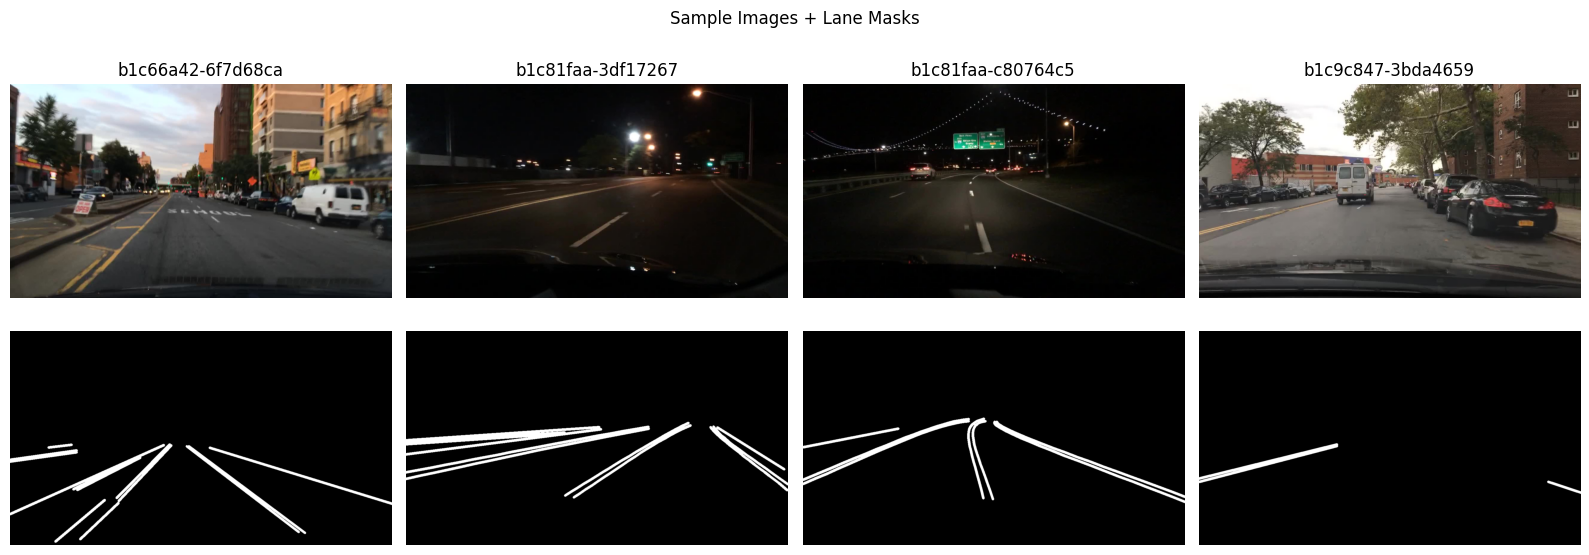

In [6]:
# ── Verify: count masks and spot-check ──
# Preview strategy follows handoff §8: try every plausible image root
# before declaring the image missing.
import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_preview_image(mask_stem: str, split: str) -> str | None:
    candidates = []
    for base in [DATASET_ROOT, BDD_IMAGES, RAW_BDD_ROOT]:
        if not base:
            continue
        base = Path(base)
        for sub in ('images/{split}', '{split}', 'bdd100k/images/100k/{split}',
                     'images/100k/{split}'):
            for ext in ('.jpg', '.jpeg', '.png'):
                candidates.append(str(base / sub.format(split=split) / f'{mask_stem}{ext}'))
    for c in candidates:
        if os.path.isfile(c):
            return c
    return None


for split in ['train', 'val']:
    mask_dir = Path(LANE_MASK_OUT) / split
    masks = sorted(mask_dir.glob('*.png'))
    print(f'{split}: {len(masks)} lane masks')

val_masks = sorted((Path(LANE_MASK_OUT) / 'val').glob('*.png'))[:4]
if not val_masks:
    print('[warn] No validation lane masks to preview. Check earlier cells for skip messages.')
else:
    fig, axes = plt.subplots(2, len(val_masks), figsize=(4 * len(val_masks), 6))
    if len(val_masks) == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for i, mask_path in enumerate(val_masks):
        mask = cv2.imread(str(mask_path), 0)
        img_path = find_preview_image(mask_path.stem, 'val')
        img = cv2.imread(img_path) if img_path is not None else None
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[0, i].imshow(img)
        else:
            axes[0, i].text(0.5, 0.5, 'image not found', ha='center', va='center')
            print(f'[warn] preview image not found for {mask_path.stem}. '
                  f'Tried roots under DATASET_ROOT / BDD_IMAGES / RAW_BDD_ROOT.')
        axes[0, i].set_title(mask_path.stem[:20])
        axes[1, i].imshow(mask, cmap='gray')
        axes[0, i].axis('off'); axes[1, i].axis('off')
    plt.suptitle('Sample Images + Lane Masks')
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Smoke-test dataset pipeline ──
# Fix vs the last run: we force the raw-BDD layout (Case C in
# AutoDriveDataset._resolve_split_paths) by clearing cfg.DATASET.ROOT.
# Otherwise the packaged-root detector picks the (newly-empty) images/
# and labels/ dirs and returns 0 samples.
from lib.config import cfg
from lib.dataset import BddDataset
from torch.utils.data import DataLoader
import torchvision.transforms as T

if not (BDD_IMAGES and BDD_LABELS and os.path.isdir(os.path.join(BDD_IMAGES, 'val'))
        and os.path.isdir(os.path.join(BDD_LABELS, 'val'))):
    print('[skip] BDD_IMAGES / BDD_LABELS not resolved; cannot run dataset smoke test.')
else:
    cfg.defrost()
    cfg.DATASET.ROOT = ''                 # <- disables "packaged_root" detection
    cfg.DATASET.DATAROOT = BDD_IMAGES     # e.g. /content/bdd100k_raw/100k
    cfg.DATASET.LABELROOT = BDD_LABELS    # e.g. /content/bdd100k_raw/100k (same dir — det+lane JSONs share it)
    cfg.DATASET.LANEROOT = LANE_MASK_OUT  # /content/bdd100k_vehicle5/masks
    cfg.freeze()

    val_dataset = BddDataset(cfg, is_train=False, inputsize=640, transform=T.ToTensor())
    print(f'Val dataset: {len(val_dataset)} samples')
    if len(val_dataset) == 0:
        print('[warn] dataset smoke test found zero samples.')
        print('       Expected layout printed by AutoDriveDataset above; compare against')
        print(f'       images dir:   {os.path.join(BDD_IMAGES, "val")}')
        print(f'       labels dir:   {os.path.join(BDD_LABELS, "val")}')
        print(f'       masks dir:    {os.path.join(LANE_MASK_OUT, "val")}')
    else:
        val_loader = DataLoader(
            val_dataset, batch_size=4, shuffle=False, num_workers=0,
            collate_fn=val_dataset.collate_fn,
        )
        img, target, paths, shapes = next(iter(val_loader))
        det_labels, lane_labels = target
        print(f'Image batch shape:  {img.shape}')
        print(f'Det labels shape:   {det_labels.shape}')
        print(f'Lane labels shape:  {lane_labels.shape}')
        print('Dataset pipeline OK!')

In [ ]:
# ── Persist rebuilt dataset back to Drive as ONE compressed archive ──
#
# Drive I/O rule (handoff §14): never write many small files directly to
# Drive. 80k individual PNGs take tens of minutes to `shutil.copytree`
# and stall on rate limits. We therefore:
#   1. Build a compressed tar on the local SSD (fast).
#   2. Copy the single archive file to Drive (one I/O op).
#
# Shared-datasets rule: archive goes under ECOCAR_ROOT/datasets/, not
# PROJECT_ROOT/datasets/, so every pipeline in the EcoCAR folder can
# reuse the same tar.gz.
#
# Downstream notebooks use `ensure_local_dataset_from_drive(ECOCAR_ROOT)`
# which already knows how to extract a .tar.gz from Drive back to
# /content on a fresh runtime.
import os
import shutil
import tarfile
import time
from pathlib import Path

DRIVE_DATASETS_DIR = Path(ECOCAR_ROOT) / 'datasets'
DRIVE_DATASETS_DIR.mkdir(parents=True, exist_ok=True)

# Local (fast SSD) staging path for the archive.
LOCAL_ARCHIVE = Path(f'/content/{DATASET_NAME}.tar.gz')
DRIVE_ARCHIVE = DRIVE_DATASETS_DIR / f'{DATASET_NAME}.tar.gz'

local_root = Path(DATASET_ROOT).resolve()
mask_dir = local_root / 'masks'

mask_count = len(list(mask_dir.glob('**/*.png'))) if mask_dir.exists() else 0
if mask_count == 0:
    print(f'[warn] {mask_dir} has 0 PNGs — not producing archive.')
else:
    # Build archive locally. The real win is reducing ~{mask_count}
    # small-file syscalls on Drive to 1.
    if LOCAL_ARCHIVE.exists():
        LOCAL_ARCHIVE.unlink()
    t0 = time.time()
    print(f'Packing {mask_count} files -> {LOCAL_ARCHIVE} ...')
    with tarfile.open(LOCAL_ARCHIVE, 'w:gz', compresslevel=6) as tar:
        # arcname is DATASET_NAME so the archive extracts to
        # /content/bdd100k_vehicle5/... on the next run.
        tar.add(str(local_root), arcname=DATASET_NAME)
    print(f'  archive built in {time.time() - t0:.1f}s, '
          f'size {LOCAL_ARCHIVE.stat().st_size / 1024**2:.1f} MiB')

    # Single-file upload to Drive.
    t0 = time.time()
    if DRIVE_ARCHIVE.exists():
        DRIVE_ARCHIVE.unlink()
    print(f'Copying archive to Drive -> {DRIVE_ARCHIVE} ...')
    shutil.copy2(LOCAL_ARCHIVE, DRIVE_ARCHIVE)
    print(f'  drive upload in {time.time() - t0:.1f}s')

    # Opportunistic cleanup of the legacy uncompressed .tar at both the
    # new (ECOCAR) and old (project-local) locations. Silent-ok failures.
    for legacy_tar in [
        DRIVE_DATASETS_DIR / f'{DATASET_NAME}.tar',
        Path(PROJECT_ROOT) / 'datasets' / f'{DATASET_NAME}.tar',
        Path(PROJECT_ROOT) / 'datasets' / f'{DATASET_NAME}.tar.gz',
    ]:
        try:
            if legacy_tar.exists():
                legacy_tar.unlink()
                print(f'  removed legacy archive: {legacy_tar}')
        except OSError:
            pass

    # Legacy uncompressed Drive directory warning (user decides).
    for legacy_dir in [
        DRIVE_DATASETS_DIR / DATASET_NAME,
        Path(PROJECT_ROOT) / 'datasets' / DATASET_NAME,
    ]:
        if legacy_dir.exists() and legacy_dir.is_dir():
            print(f'[note] legacy uncompressed dir still present on Drive: {legacy_dir}')
            print('       Consider deleting it manually to save Drive space/quota.')

print()
print('Persisted for downstream notebooks:')
print(f'  local  : {LOCAL_ARCHIVE}  (exists: {LOCAL_ARCHIVE.exists()})')
print(f'  drive  : {DRIVE_ARCHIVE}  (exists: {DRIVE_ARCHIVE.exists()})')